# **Banco de Dados - Não Relacional**

**Instituição:** Pontifícia Universidade Católica de Campinas

**Curso:** Ciência de Dados e Inteligência Artificial

**Professor:** Felipe Cavalaro  

---

## Integrantes

| Nome | RA |
| :--- | :--- |
| Alice Pasolini | 25012938 |
| Enzo Guerra | 25007153 |
| Guilherme Cintra | 25004996 |
| Julia Leandro | 25009148 |
| Lavínia Oliveira | 25894981 |

### Instalação das Dependências

In [1]:
# pip install -r ../requirements.txt -q
# (Dependências devem estar pré-instaladas)

In [ ]:
# DataFrames e funções auxiliares
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
import csv

# Grafos
import networkx as nx

ModuleNotFoundError: No module named 'seaborn'

Conexão com MongoDB

In [ ]:
import pymongo
from pymongo import MongoClient
import os
from pathlib import Path
from dotenv import load_dotenv

# Estratégia: sempre usar o caminho relativo ../
# Isso funciona tanto no Jupyter quanto quando importado como módulo

# Assumindo que o notebook está em Notebooks/
# Procuramos o .env em ../
env_path = os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in dir() else '.', '..', '.env'))

# Debug
print(f"[DEBUG] CWD: {os.getcwd()}")
print(f"[DEBUG] Procurando .env em: {env_path}")
print(f"[DEBUG] Arquivo existe? {os.path.exists(env_path)}")

load_dotenv(env_path)

# Verificar se carregou
MONGODB_URI = os.getenv("MONGODB_URI")
print(f"[DEBUG] MONGODB_URI carregado? {bool(MONGODB_URI)}")

[DEBUG] CWD: c:\Users\jusou\OneDrive\Documentos\GitHub\pi_educacao_qualidade\Notebooks
[DEBUG] Procurando .env em: c:\Users\jusou\OneDrive\Documentos\GitHub\pi_educacao_qualidade\.env
[DEBUG] Arquivo existe? True
[DEBUG] MONGODB_URI carregado? True


### Puxando os datasets

In [ ]:
REGIAO_CAMPINAS = ['CAMPINAS','HORTOLANDIA','SUMARE','INDAIATUBA','PAULINIA','AMERICANA','VALINHOS','SANTA BARBARA D\'OESTE']

In [ ]:
# Resolver caminho relativo ao arquivo do notebook
notebook_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
CAMINHO_BASE = os.path.join(notebook_dir, "..", "Datasets Tratados")
CAMINHO_BASE = os.path.abspath(CAMINHO_BASE)

In [ ]:
def puxa_dataset(arquivo):
  url = os.path.join(CAMINHO_BASE, arquivo)
  return pd.read_csv(url, sep=',')

In [ ]:
sarespArq = "sarespDFTratado.csv"
sarespDF = puxa_dataset(sarespArq)

fluxoArq = "fluxoDFTratado.csv"
fluxoDF = puxa_dataset(fluxoArq)

ausArq = "ausDFTratado.csv"
ausDF = puxa_dataset(ausArq)

censoArq = "censoDFTratado.csv"
censoDF = puxa_dataset(censoArq)

In [ ]:
def inserir(arquivo, colecao):
  if db is None:
    print(f"Erro: MongoDB não está conectado. Não é possível inserir em '{colecao}'.")
    return
  collection = db[colecao]
  collection.delete_many({})
  with open(os.path.join(CAMINHO_BASE, arquivo), 'r', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile)
    collection.insert_many(reader)

In [ ]:
def visualizar(colecao):
  if db is None:
    print(f"Erro: MongoDB não está conectado. Não é possível visualizar '{colecao}'.")
    return
  
  lista_dfs = []
  for i in REGIAO_CAMPINAS:
      results = db[colecao].find({ "MUNICÍPIOS" : i})
      df = pd.DataFrame(list(results))

      if not df.empty:
          df = df.drop(columns=["_id"])
          lista_dfs.append(df)

  if lista_dfs:
      df = pd.concat(lista_dfs, ignore_index=True)
      print(df.to_string())
  else:
      print(f"Nenhum dado encontrado para a coleção '{colecao}'")

In [ ]:
# DataFrames e funções auxiliares
import pandas as pd
import numpy as np
import zipfile

# Formatar encoding dos arquivos
import unicodedata

# Dashboard interativo
import streamlit

# Mongo

Conexão MongoDB

In [ ]:
# Carregando a URL de conexão MongoDB a partir do arquivo .env (por segurança)
MONGODB_URI = os.getenv("MONGODB_URI")
print(f"[DEBUG] MONGODB_URI definido? {bool(MONGODB_URI)}")
print(f"[DEBUG] URI começa com 'mongodb'? {str(MONGODB_URI or '').startswith('mongodb')}")

try:
    if not MONGODB_URI:
        raise ValueError("MONGODB_URI não foi definido no .env")
    
    client = MongoClient(MONGODB_URI, serverSelectionTimeoutMS=10000)
    print(f"[DEBUG] Testando conexão com MongoDB...")
    info = client.server_info()
    print(f"✓ Conectado ao MongoDB com sucesso!")
    print(f"  Versão: {info.get('version', 'desconhecida')}")
    db = client["datasets"]
except Exception as e:
    print(f"✗ Aviso: Não foi possível conectar ao MongoDB: {e}")
    client = None
    db = None

[DEBUG] MONGODB_URI definido? True
[DEBUG] URI começa com 'mongodb'? True
[DEBUG] Testando conexão com MongoDB...
✓ Conectado ao MongoDB com sucesso!
  Versão: 8.0.23


In [ ]:
arquivos = {
    sarespArq : "saresp",
    ausArq : "ausencia",
    fluxoArq : "fluxo",
    censoArq : "censo"
}

In [ ]:
for chave, valor in arquivos.items():
  inserir(chave, valor)

Verificação da função `inserir`

In [ ]:
print("Quantidade de documentos por dataset:\n")
if db is not None:
    for nome_colecao in ["saresp", "ausencia", "fluxo", "censo"]:
        qtd = db[nome_colecao].count_documents({})
        print(f"{nome_colecao}: {qtd} documentos")
else:
    print("MongoDB não está disponível. Não é possível contar documentos.")

Quantidade de documentos por dataset:

saresp: 134 documentos
ausencia: 24 documentos
fluxo: 24 documentos
censo: 78 documentos


Visualização do documento `json` como Dataframe

In [ ]:
for itens in arquivos.values():
  visualizar(itens)

                MUNICÍPIOS   ANO  SERIE_ANO        COMPETÊNCIA MÉDIA_PROFICIÊNCIA
0                 CAMPINAS  2022  2º Ano EF  LÍNGUA PORTUGUESA             178.67
1                 CAMPINAS  2022  2º Ano EF         MATEMÁTICA             186.57
2                 CAMPINAS  2022  5º Ano EF  LÍNGUA PORTUGUESA             195.97
3                 CAMPINAS  2022  5º Ano EF         MATEMÁTICA             210.67
4                 CAMPINAS  2022  9º Ano EF  LÍNGUA PORTUGUESA             237.18
5                 CAMPINAS  2022  9º Ano EF         MATEMÁTICA             242.05
6                 CAMPINAS  2023  2º Ano EF  LÍNGUA PORTUGUESA             171.73
7                 CAMPINAS  2023  2º Ano EF         MATEMÁTICA             163.45
8                 CAMPINAS  2023  5º Ano EF  LÍNGUA PORTUGUESA             194.07
9                 CAMPINAS  2023  5º Ano EF         MATEMÁTICA             205.82
10                CAMPINAS  2023  9º Ano EF  LÍNGUA PORTUGUESA             227.28
11              

---
## **📊 | GRAFOS**

---
## **📊 | ANÁLISE EXPLORATÓRIA**

count    134.000000
mean     209.008507
std       34.277474
min      117.070000
25%      179.215000
50%      211.120000
75%      241.617500
max      262.530000
Name: MÉDIA_PROFICIÊNCIA, dtype: float64


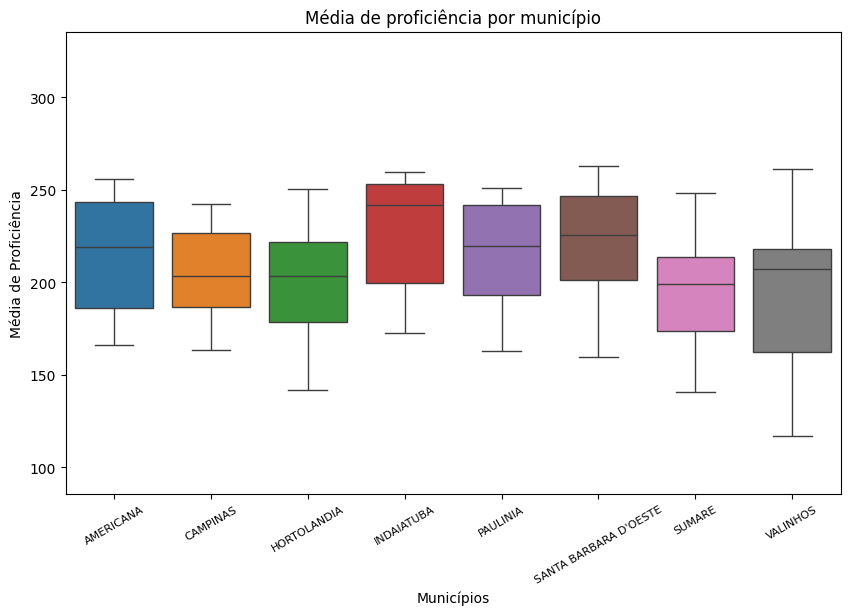

In [ ]:
# Cálculo dos limites para tratar os outliers
Q1 = sarespDF['MÉDIA_PROFICIÊNCIA'].quantile(0.25)

Q3 = sarespDF['MÉDIA_PROFICIÊNCIA'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# -----------------------------------

print(sarespDF['MÉDIA_PROFICIÊNCIA'].describe())
plt.figure(figsize=(10, 6))
sns.boxplot(data=sarespDF, x=sarespDF.MUNICÍPIOS, y=sarespDF.MÉDIA_PROFICIÊNCIA, hue=sarespDF["MUNICÍPIOS"])
plt.title("Média de proficiência por município")
plt.xticks(fontsize=8, rotation=30)
plt.xlabel("Municípios")
plt.ylabel("Média de Proficiência")
plt.ylim(limite_inferior,limite_superior)
plt.show()